# 🔍 상품 상세 이미지 OCR 모델 성능 및 비용 비교 분석
> **목적**: 이커머스 상품 상세 이미지 텍스트 추출 최적 모델 선정  
> **비교 대상**: Gemini 2.5 (Flash-Lite / Flash / Pro), Cloud Vision API

---
## 📋 목차
1. [환경 설정 및 라이브러리 임포트](#1)
2. [클라이언트 초기화](#2)
3. [테스트 이미지 로드 및 미리보기](#3)
4. [Gemini 계열 OCR 추출](#4)
5. [Cloud Vision API OCR 추출](#5)
6. [정량 지표 측정 (CER / WER)](#6)
7. [Latency 비교](#7)
8. [비용 계산 및 시뮬레이션](#8)
9. [종합 비교 시각화](#9)
10. [결과 저장](#10)

---
## 1. 환경 설정 및 라이브러리 임포트 <a id="1"></a>

In [1]:
# 최초 1회 실행
# !pip install google-genai google-cloud-vision \
#              jiwer Pillow pandas matplotlib seaborn tqdm python-dotenv

In [2]:
import os, time, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from dotenv import load_dotenv

from google import genai
from google.genai import types
from google.cloud import vision
from jiwer import cer, wer
import re

# ── 한글 폰트 설정 ───────────────────────────────────────────
# Mac: "AppleGothic" / Linux: "NanumGothic" / Windows: "Malgun Gothic"
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

print("✅ 라이브러리 임포트 완료")

✅ 라이브러리 임포트 완료


---
## 2. API 키 설정 및 클라이언트 초기화 <a id="2"></a>

In [3]:
load_dotenv()

# ── GCP ──────────────────────────────────────────────────────
# 사전 인증: gcloud auth application-default login
GCP_PROJECT_ID = os.getenv("GCP_PROJECT_ID", "your-gcp-project-id")
GCP_LOCATION   = os.getenv("GCP_LOCATION",   "us-central1")

# ── Gemini (Vertex AI, API 키 불필요) ────────────────────────
client = genai.Client(
    vertexai=True,
    project=GCP_PROJECT_ID,
    location=GCP_LOCATION,
)

vision_client = vision.ImageAnnotatorClient()

print("✅ 클라이언트 초기화 완료")
print(f"   Gemini (Vertex AI) : project={GCP_PROJECT_ID}, location={GCP_LOCATION}")

✅ 클라이언트 초기화 완료
   Gemini (Vertex AI) : project=groobee-ai, location=us-central1


I0000 00:00:1771588159.897770 1121077 check_gcp_environment_no_op.cc:29] ALTS: Platforms other than Linux and Windows are not supported


In [4]:
# ── 비교 모델 정의 (Vertex AI 지원 모델 ID) ──────────────────
GEMINI_MODELS = {
    "gemini-2.5-flash-lite" : "Gemini 2.5 Flash-Lite",
    "gemini-2.5-flash"      : "Gemini 2.5 Flash",
    "gemini-2.5-pro"        : "Gemini 2.5 Pro",
}

# ── 가격 정의 (USD / 1M tokens, Vertex AI 기준) ───────────────
# 출처: https://cloud.google.com/vertex-ai/generative-ai/pricing
PRICING = {
    "gemini-2.5-flash-lite" : {"input": 0.10,  "output": 0.40},
    "gemini-2.5-flash"      : {"input": 0.30,  "output": 2.50},
    "gemini-2.5-pro"        : {"input": 1.25,  "output": 10.00},  # ≤200K 기준
    "cloud-vision"          : {"per_unit": 1.50 / 1000},
}

print("✅ 모델 정의 완료")
for k, v in GEMINI_MODELS.items():
    p = PRICING[k]
    print(f"   {k:<25} → {v:<25} (input ${p['input']:.2f} / output ${p['output']:.2f} per 1M tokens)")

✅ 모델 정의 완료
   gemini-2.5-flash-lite     → Gemini 2.5 Flash-Lite     (input $0.10 / output $0.40 per 1M tokens)
   gemini-2.5-flash          → Gemini 2.5 Flash          (input $0.30 / output $2.50 per 1M tokens)
   gemini-2.5-pro            → Gemini 2.5 Pro            (input $1.25 / output $10.00 per 1M tokens)


---
## 3. 테스트 이미지 로드 및 미리보기 <a id="3"></a>

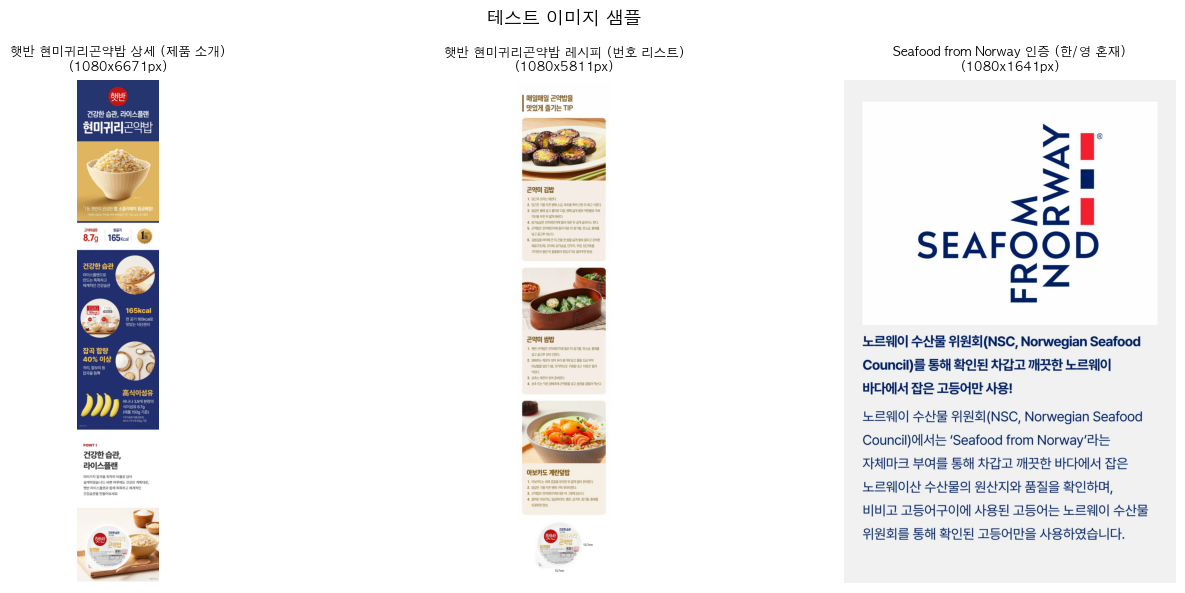

   ✅  img_01_product: images/img_01_hatban_product.png
   ✅  img_02_recipe: images/img_02_hatban_recipe.png
   ✅  img_03_cert: images/img_03_seafood_norway.png


In [5]:
IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)

TEST_IMAGES = {
    "img_01_product": {
        "path": IMAGE_DIR / "img_01_hatban_product.png",
        "desc": "햇반 현미귀리곤약밥 상세 (제품 소개)",
        "type": "product_detail",
    },
    "img_02_recipe": {
        "path": IMAGE_DIR / "img_02_hatban_recipe.png",
        "desc": "햇반 현미귀리곤약밥 레시피 (번호 리스트)",
        "type": "recipe",
    },
    "img_03_cert": {
        "path": IMAGE_DIR / "img_03_seafood_norway.png",
        "desc": "Seafood from Norway 인증 (한/영 혼재)",
        "type": "certification",
    },
}

def load_image_bytes(path: Path) -> bytes:
    with open(path, "rb") as f:
        return f.read()

# ── 이미지 미리보기 ───────────────────────────────────────────
fig, axes = plt.subplots(1, len(TEST_IMAGES), figsize=(15, 6))
for ax, (key, meta) in zip(axes, TEST_IMAGES.items()):
    try:
        img = Image.open(meta["path"])
        ax.imshow(img)
        ax.set_title(f"{meta['desc']}\n({img.size[0]}x{img.size[1]}px)", fontsize=9)
    except FileNotFoundError:
        ax.text(0.5, 0.5, f"파일 없음\n{meta['path']}", ha="center", va="center",
                transform=ax.transAxes, color="red")
        ax.set_title(key)
    ax.axis("off")
plt.suptitle("테스트 이미지 샘플", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

for k, v in TEST_IMAGES.items():
    exists = "✅" if v["path"].exists() else "⚠️  파일 없음"
    print(f"   {exists}  {k}: {v['path']}")

---
## 4. Gemini 계열 OCR 추출 <a id="4"></a>

In [6]:
OCR_PROMPT = """이 이미지에서 모든 텍스트를 정확하게 추출해주세요.

규칙:
1. 이미지에 보이는 텍스트를 빠짐없이 추출
2. 원본 레이아웃(줄바꿈, 리스트 순서, 표 구조)을 최대한 유지
3. 한국어, 영어, 한자, 숫자, 특수문자 모두 포함
4. 이미지 설명이나 부연 설명 없이 텍스트만 출력
5. 텍스트가 여러 열/영역에 있을 경우 시각적 순서(위→아래, 왼→오른)로 출력

추출된 텍스트:"""


In [7]:
from concurrent.futures import ThreadPoolExecutor, as_completed

N_REPEAT = 3  # latency 평균 계산용 반복 횟수

def gemini_ocr(model_id: str, image_path: Path, prompt: str = OCR_PROMPT) -> dict:
    """Gemini 단일 호출 — start는 로컬 변수이므로 병렬 실행 시에도 latency 독립 측정"""
    result = {"model_id": model_id, "text": "", "input_tokens": 0,
              "output_tokens": 0, "latency_ms": 0, "error": None}
    try:
        img_bytes = image_path.read_bytes()
        mime_type = "image/png" if image_path.suffix.lower() == ".png" else "image/jpeg"

        start = time.perf_counter()                          # ← 스레드마다 독립적인 로컬 변수
        resp = client.models.generate_content(
            model=model_id,
            contents=[
                types.Part.from_bytes(data=img_bytes, mime_type=mime_type),
                types.Part.from_text(text=prompt),
            ],
            config=types.GenerateContentConfig(
                temperature=0,
                max_output_tokens=4096,
            ),
        )
        result["latency_ms"]    = round((time.perf_counter() - start) * 1000, 1)
        result["text"]          = resp.text.strip()
        result["input_tokens"]  = resp.usage_metadata.prompt_token_count
        result["output_tokens"] = resp.usage_metadata.candidates_token_count
    except Exception as e:
        result["error"] = str(e)
    return result


def _run_single_model(model_id: str, display_name: str, image_path: Path) -> dict:
    """단일 모델 N_REPEAT 순차 실행 → 개별 latency 평균 반환"""
    latencies, last_ok, last_err = [], None, None
    for _ in range(N_REPEAT):
        r = gemini_ocr(model_id, image_path)
        if r["error"]:
            last_err = r["error"]
        else:
            latencies.append(r["latency_ms"])
            last_ok = r

    success = last_ok is not None
    return {
        "model_id":      model_id,
        "display_name":  display_name,
        "text":          last_ok["text"]          if success else "",
        "latency_ms":    round(np.mean(latencies), 1) if success else None,
        "input_tokens":  last_ok["input_tokens"]  if success else 0,
        "output_tokens": last_ok["output_tokens"] if success else 0,
        "error":         None if success else last_err,
    }


def run_gemini_all(image_path: Path, max_workers: int = 5) -> list:
    """모든 Gemini 모델 병렬 실행 — GEMINI_MODELS 정의 순서 보장"""
    model_items = list(GEMINI_MODELS.items())
    results = [None] * len(model_items)

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_idx = {
            executor.submit(_run_single_model, model_id, display_name, image_path): idx
            for idx, (model_id, display_name) in enumerate(model_items)
        }
        for future in as_completed(future_to_idx):
            results[future_to_idx[future]] = future.result()

    return results

In [8]:
# ── 실행 (이미지 간 병렬) ─────────────────────────────────────
gemini_results = {}

def _process_image(img_key: str, meta: dict) -> tuple:
    if not meta["path"].exists():
        return img_key, []
    return img_key, run_gemini_all(meta["path"])

print(f"▶ Gemini OCR 시작  (모델 {len(GEMINI_MODELS)}개 × 이미지 {len(TEST_IMAGES)}장 × {N_REPEAT}회 반복)\n")

with ThreadPoolExecutor(max_workers=len(TEST_IMAGES)) as executor:
    futures = {executor.submit(_process_image, k, v): k for k, v in TEST_IMAGES.items()}
    for future in as_completed(futures):
        img_key, results = future.result()
        gemini_results[img_key] = results

# ── 결과 출력 (이미지·모델 정의 순서 기준) ───────────────────
print(f"{'모델':<25} {'latency(avg ms)':>15} {'input tok':>10} {'output tok':>11}  상태")
print("─" * 70)
for img_key, meta in TEST_IMAGES.items():
    print(f"\n📄 {meta['desc']}")
    for r in gemini_results.get(img_key, []):
        if r["error"]:
            status = f"❌ {r['error'][:40]}"
            lat = input_tok = output_tok = "-"
        else:
            status = "✅"
            lat       = f"{r['latency_ms']:,.1f}"
            input_tok = str(r["input_tokens"])
            output_tok = str(r["output_tokens"])
        print(f"  {r['display_name']:<23} {lat:>15} {input_tok:>10} {output_tok:>11}  {status}")

print("\n✅ Gemini OCR 완료")

▶ Gemini OCR 시작  (모델 3개 × 이미지 3장 × 3회 반복)

모델                        latency(avg ms)  input tok  output tok  상태
──────────────────────────────────────────────────────────────────────

📄 햇반 현미귀리곤약밥 상세 (제품 소개)
  Gemini 2.5 Flash-Lite          13,636.2       3484         380  ✅
  Gemini 2.5 Flash               10,993.3       3484         426  ✅
  Gemini 2.5 Pro                 24,850.7       3484         610  ✅

📄 햇반 현미귀리곤약밥 레시피 (번호 리스트)
  Gemini 2.5 Flash-Lite           5,405.6       3484         591  ✅
  Gemini 2.5 Flash                7,298.7       3484         594  ✅
  Gemini 2.5 Pro                 28,633.7       3484         611  ✅

📄 Seafood from Norway 인증 (한/영 혼재)
  Gemini 2.5 Flash-Lite           3,539.3       1936         158  ✅
  Gemini 2.5 Flash                4,193.6       1936         156  ✅
  Gemini 2.5 Pro                 27,171.4       1936         153  ✅

✅ Gemini OCR 완료


In [9]:
# ── 결과 미리보기 ─────────────────────────────────────────────
for img_key, results in gemini_results.items():
    print(f"\n{'─'*65}")
    print(f"📄 {TEST_IMAGES[img_key]['desc']}")
    for r in results:
        preview = (r["text"][:200].replace("\n", " ") + "...") if r["text"] else "(없음)"
        print(f"\n  [{r['display_name']}]")
        print(f"  텍스트 : {preview}")
        print(f"  토큰   : input={r.get('input_tokens','-')}, output={r.get('output_tokens','-')}")
        print(f"  latency: {r.get('latency_ms','-')} ms")


─────────────────────────────────────────────────────────────────
📄 햇반 현미귀리곤약밥 상세 (제품 소개)

  [Gemini 2.5 Flash-Lite]
  텍스트 : 햇반 건강한 습관, 라이스플랜 현미귀리곤약밥 연출이미지 *1등 햇반이 완성한 밥 소믈리에의 황금배합! *2001-2024, 즉석밥 부문 판매실적 1위 기업, 닐슨 조사결과 고식이섬유 한공기 8.7g 165 Kcal 대한민국 등 건강한 습관 라이스플랜으로 만드는 똑똑하고 체계적인 건강습관 150G 110G 165kcal 165kcal 165kcal 한 공기 ...
  토큰   : input=3484, output=380
  latency: 13636.2 ms

  [Gemini 2.5 Flash]
  텍스트 : 햇반 건강한 습관, 라이스플랜 현미귀리곤약밥 연출이미지 *1등 햇반이 완성한 밥 소믈리에의 황금배합! *2001-2024, 즉석밥 부문 판매실적 1위 기업, 닐슨 조사결과 고식이섬유 8.7g 한공기 165Kcal 대한민국 1등 2001-2024, 닐슨 조사결과 건강한 습관 라이스플랜으로 만드는 똑똑하고 체계적인 건강습관 150G 165kcal 110G 16...
  토큰   : input=3484, output=426
  latency: 10993.3 ms

  [Gemini 2.5 Pro]
  텍스트 : 햇반® 건강한 습관, 라이스플랜 현미귀리곤약밥  연출이미지  *1등 햇반이 완성한 밥 소믈리에의 황금배합! *2001-2024, 즉석밥 부문 판매실적 1위 기업, 닐슨 조사결과  고식이섬유 8.7g  한공기 165Kcal  대한민국 1등 2001-2024 즉석밥 부문 판매실적 1위 기업  건강한 습관 라이스플랜으로 만드는 똑똑하고 체계적인 건강습관  150...
  토큰   : input=3484, output=610
  latency: 24850.7 ms

─────────────────────────────────────────

---
## 5. Cloud Vision API OCR 추출 <a id="5"></a>

In [10]:
def cloud_vision_ocr(image_path: Path) -> dict:
    result = {"model_id": "cloud-vision", "display_name": "Cloud Vision API",
              "text": "", "latency_ms": None, "error": None}
    try:
        img_bytes = load_image_bytes(image_path)
        image     = vision.Image(content=img_bytes)
        feature   = vision.Feature(type_=vision.Feature.Type.TEXT_DETECTION)
        latencies, full_text = [], ""
        for _ in range(N_REPEAT):
            start    = time.perf_counter()
            response = vision_client.annotate_image({"image": image, "features": [feature]})
            latencies.append((time.perf_counter() - start) * 1000)
            if not response.error.message:
                full_text = response.full_text_annotation.text
        result["text"]       = full_text.strip()
        result["latency_ms"] = round(np.mean(latencies), 1)
        if response.error.message:
            result["error"] = response.error.message
    except Exception as e:
        result["error"] = str(e)
        print(f"  ⚠️  Cloud Vision: {e}")
    return result


# ── 실행 ─────────────────────────────────────────────────────
vision_results = {}
for img_key, meta in TEST_IMAGES.items():
    print(f"📤 Cloud Vision — {meta['desc']}", end=" ... ")
    if not meta["path"].exists():
        print("⚠️ 파일 없음")
        vision_results[img_key] = {}
        continue
    r = cloud_vision_ocr(meta["path"])
    vision_results[img_key] = r
    print(f"✅ {r['latency_ms']}ms" if not r["error"] else f"❌ {r['error']}")

print("\n✅ Cloud Vision OCR 완료")

📤 Cloud Vision — 햇반 현미귀리곤약밥 상세 (제품 소개) ... ✅ 4293.8ms
📤 Cloud Vision — 햇반 현미귀리곤약밥 레시피 (번호 리스트) ... ✅ 855.3ms
📤 Cloud Vision — Seafood from Norway 인증 (한/영 혼재) ... ✅ 454.7ms

✅ Cloud Vision OCR 완료


---
## 6. 정량 지표 측정 (CER / WER) <a id="6"></a>

### 📐 OCR 성능 평가 지표 조사 요약

OCR 평가 지표는 태스크 목적에 따라 크게 세 계열로 나뉜다.

| 계열 | 대표 지표 | 주 사용처 |
|---|---|---|
| **문자/단어 편집거리** | CER, WER, NED | 인쇄·필기 문서 OCR, 역사 문서 디지털화 |
| **의미적 유사도** | ANLS, ANLS*, VQA Accuracy | DocVQA, LLM/VLM 기반 문서 이해 |
| **구조 인식** | TEDS, GriTS, CDM | 표(Table), 수식(Formula) 인식 |

#### 각 지표별 핵심 특성

| 지표 | 출처 | 장점 | 단점 |
|---|---|---|---|
| **CER** | 고전 (40년+) | 문자 단위 세밀한 측정, 언어 무관 | 삽입 오류 시 100% 초과 가능 |
| **WER** | 고전 | 단어 완전성 평가, 직관적 | CER보다 항상 높음, 한국어 단어 경계 모호 |
| **ANLS** | DocVQA, WACV 2021 | OCR 소오류 관대 (τ=0.5), 복수 정답 | 의미 비슷하면 정답 처리 → 정밀 추출엔 부적합 |
| **ANLS\*** | ACL 2024 | 딕셔너리·리스트 구조 지원, 할루시네이션 패널티 | 구현 복잡 |
| **TEDS** | ECCV 2020 | 표 셀 병합·구조 반영 | 표 전용, 연산 비용 큼 |
| **CDM** | CVPR 2025 | 수식 LaTeX 표현 다양성 문제 해결 (이미지 렌더링 비교) | 수식 전용 |
| **LLM-as-Judge** | 2024~2025 | 의미적 동등성 포착 | 편향(Position/Verbosity Bias), 비용, 재현성 문제 |

#### 최신 벤치마크 지표 조합 (2024~2025)

- **OCRBench v2** (2025): TEDS / IoU / F1 / BLEU / ANLS 태스크별 혼용 (0~100점)
- **OmniDocBench** (CVPR 2025): `(NED×100 + TEDS + CDM) / 3` 종합 점수
- **CC-OCR** (2024): F1 + NED + TEDS + 반복비율(할루시네이션 검출)

---

### ✅ 본 실험의 지표 선택: **CER + WER**

> **목표**: 이미지 내 텍스트를 의미 변형 없이 **원문 그대로** 추출하는 능력 측정

- **ANLS 제외 이유**: τ=0.5 임계값으로 소오류를 관대하게 처리 → 정밀 추출 비교에 부적합
- **TEDS/CDM 제외 이유**: 표·수식 전용 지표, 이커머스 상세 이미지 텍스트에 불필요
- **CER 선택**: 문자 하나하나의 정확도를 측정 → 원문 그대로 추출 여부 판단에 가장 적합
- **WER 선택**: 단어 단위 완전 일치 여부 보조 측정

> ⚠️ **CER > 100% 해석**: 모델이 GT보다 훨씬 많은 텍스트를 추출했을 때 발생 (삽입 오류 과다).  
> 이는 GT의 완성도 부족 또는 모델의 과잉 추출(hallucination) 신호로 해석.

In [27]:
# ── Ground Truth 입력 ─────────────────────────────────────────
# ⚠️ 이미지를 직접 보고 GT를 정확하게 입력하세요
GROUND_TRUTH = {
    "img_01_product": """햇반®

건강한 습관, 라이스플랜
현미귀리곤약밥

연출이미지

*1등 햇반이 완성한 밥 소믈리에의 황금배합!
*2001-2024, 즉석밥 부문 판매실적 1위 기업, 닐슨 조사결과

고식이섬유
8.7g

한공기
165Kcal

대한민국 1등
2001-2024, 즉석밥 부문 판매실적 1위 기업, 닐슨 조사결과

건강한 습관
라이스플랜으로
만드는 똑똑하고
체계적인 건강습관

150G
165kcal
건강한 습관
햇반 현미귀리 곤약밥

110G
165kcal
햇반

165kcal
한 공기 165kcal로
맛있는 식단관리

잡곡 함량
40% 이상
귀리, 찰보리 등
잡곡을 듬뿍

연출이미지

高식이섬유
바나나 3.9개 분량의
식이섬유 8.7g
(제품 150g 기준)
*국가표준식품성분표,
바나나 약 1개 100g 기준

POINT 1
건강한 습관,
라이스플랜
여러가지 잡곡을 최적의 비율로 담아
설계하였습니다. 바쁜 하루에도 건강은 계획대로,
햇반 라이스플랜과 함께 똑똑하고 체계적인
건강습관을 만들어보세요.

건강한 습관
라이스플랜
햇반® 현미귀리
곤약밥

165 kcal 1인분 (150 g)
곤약쌀 33 %(곤약분말 10 %), 귀리 28 %, 찰보리 14 %, 현미 11 %
식품유형 : 현미귀리곤약밥 / 150 g(165 kcal)
*조리 전에 절취선까지 뜯으세요.

700 W 2분
1000 W 1분 30초
끓는 물 10분

• 제품명 : 햇반 현미귀리곤약밥 • 원재료명 : 곤약쌀[타피오카전분(외국산), 곤약분말(중국산)],
정제수, 귀리(캐나다산), 찰보리(국산), 현미(국산), 현미농축액, 쌀미강추출물
• 포장재질: 폴리프로필렌(내면) • 보관방법: 실온보관 • 반품 및 교환처 : 전국 판매점 및 대리점
• 본 제품은 소비자분쟁해결기준에 의거 교환 또는 보상받을 수 있습니다.
• 부정·불량식품 신고는 국번없이 1399 • 이 제품은 알류, 우유, 메밀, 땅콩, 대두, 밀, 고등어, 게, 새우,
돼지고기, 복숭아, 토마토, 아황산류, 호두, 닭고기, 쇠고기, 오징어, 조개류(굴, 전복, 홍합 포함), 잣을 사용한 제품과 같은 제조시설에서 제조하고 있습니다.
• 소비기한 : 밑면 표기일까지 • 고객행복센터 : 080-850-1200
• 조리 후 남은 제품은 변질 우려가 있으니 가급적 빨리 드십시오. • 가열된 용기는 매우 뜨거우므로 화상에 주의하십시오.
• 취급 중 포장이 손상되면 제품 변질의 우려가 있으니 주의하십시오.
• 곤약쌀의 특성상 밥에 갈색/검은 반점이 있을 수 있으나, 품질에는 이상이 없으니 안심하고 드셔도 됩니다.
• 전자레인지 조리시, 반드시 절취선까지 뜯고 조리하십시오.

영양정보 총 내용량 150 g / 165 kcal
나트륨 10 mg 1% 탄수화물 35 g 11% 당류 0 g 0%
식이섬유 8.7 g 35% 지방 1.2 g 2% 트랜스지방 0 g
포화지방 0.3 g 2% 콜레스테롤 0 mg 0% 단백질 4 g 7%
1일 영양성분 기준치에 대한 비율(%)은 2,000kcal 기준이므로 개인의 필요 열량에 따라 다를 수 있습니다.
비닐류 OTHER

뜯는곳

연출이미지""",

    "img_02_recipe": """매일매일 곤약밥을
맛있게 즐기는 TIP

조리예

곤약미 김밥

당근과 오이는 채썬다.
당근은 기름 두른 팬에 소금, 후추를 뿌려 간한 뒤 볶고 식힌다.
달걀은 볼에 넣고 풀어준 다음, 팬에 넓게 펼쳐 약한불로 익혀 지단을 부친 뒤 얇게 채썬다.
닭가슴살은 전자레인지에 돌려 데운 뒤 길게 슬라이스 한다.
곤약밥은 전자레인지에 돌려 데운 뒤 참기름, 맛소금, 통깨를 넣고 골고루 섞는다.
김밥김을 바닥에 깐 뒤 간을 한 밥을 넓게 펼쳐 올리고 준비한 재료(지단채, 오이채, 닭가슴살, 단무지, 우엉, 당근채)를 가지런히 올린 뒤 돌돌말아 한입크기로 썰어주면 완성.
조리예

곤약미 쌈밥

햇반 곤약밥은 전자레인지에 돌린 뒤 참기름, 맛소금, 통깨를 넣고 골고루 섞어 간한다.
양배추는 깨끗이 씻어 유리 용기에 담고 물을 조금 부어 비닐랩을 덮은 다음, 젓가락으로 구멍을 내고 10분간 돌려 익힌다.
상추는 깨끗이 씻어 준비한다.
상추 또는 익힌 양배추에 곤약밥을 넣고 쌈장을 곁들여 먹는다.
조리예

아보카도 계란덮밥

아보카도는 씨와 껍질을 분리한 뒤 얇게 썰어 준비한다.
달걀은 기름 두른 팬에 구워 후라이한다.
곤약밥은 전자레인지에 데운 뒤 그릇에 담는다.
썰어둔 아보카도, 달걀후라이, 명란, 김가루, 참기름, 통깨를 토핑하면 완성.
건강한 습관
라이스플랜
햇반® 현미귀리
곤약밥

13.7cm

165 kcal (150 g) 1인분 (150 g)
곤약쌀 33 % (곤약분말 10 %), 귀리 26 %, 찰보리 14 %, 현미 11 %
제품명 : 현미귀리곤약밥 / 150 g (165 kcal)

조리용 용기 및 파우치 사용금지
비닐류 OTHER
• 원재료명: 곤약쌀[타피오카전분(태국산), 곤약분말(중국산)], 멥쌀(국산), 귀리(캐나다산), 찰보리(국산), 현미(국산), 쌀미강추출물 영양정보 총 내용량 150g / 165 kcal 나트륨 10 mg 1% 탄수화물 34 g 10% 당류 0 g 0% 지방 1.5 g 3% 트랜스지방 0 g 포화지방 0.5 g 3% 콜레스테롤 0 mg 0% 단백질 4 g 7% 1일 영양성분 기준치에 대한 비율(%)은 2,000kcal 기준이므로 개인의 필요 열량에 따라 다를 수 있습니다.
• 식품의 유형: 즉석조리식품 • 제조원: 씨제이제일제당(주) 부산공장 부산광역시 사하구 다대로 210 • 포장재질(내면): 폴리프로필렌(용기), 폴리프로필렌, 에틸렌비닐알콜공중합체, 폴리에틸렌테레프탈레이트(리드필름)
• 보관방법: 실온보관 • 주의사항: 포장이 손상되면 제품 변질의 우려가 있으니 주의하시기 바랍니다. • 부정·불량식품 신고는 국번없이 1399
• 이 제품은 메밀, 땅콩, 잣, 대두, 밀, 고등어, 게, 새우, 돼지고기, 복숭아, 토마토, 아황산류, 호두, 닭고기, 쇠고기, 오징어, 조개류(굴, 전복, 홍합 포함)를 사용한 제품과 같은 제조시설에서 제조하고 있습니다.
• 소비자기본법에 따른 피해 보상 • 개봉 시 포장재질에 베일 수 있으니 주의하십시오. • 교환/반품: 구입처 및 씨제이제일제당(주) 고객행복센터 080-850-1200
전자레인지 조리시 화상에 주의하십시오. (조리 후 용기가 뜨거울 수 있습니다.)

▲뜯는곳

13.7cm""",

    "img_03_cert": """SEAFOOD FROM NORWAY ®

노르웨이 수산물 위원회(NSC, Norwegian Seafood
Council)를 통해 확인된 차갑고 깨끗한 노르웨이
바다에서 잡은 고등어만 사용!

노르웨이 수산물 위원회(NSC, Norwegian Seafood
Council)에서는 ‘Seafood from Norway’라는
자체마크 부여를 통해 차갑고 깨끗한 바다에서 잡은
노르웨이산 수산물의 원산지와 품질을 확인하며,
비비고 고등어구이에 사용된 고등어는 노르웨이 수산물
위원회를 통해 확인된 고등어만을 사용하였습니다.""",
}

def normalize_text(text: str) -> str:
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def compute_metrics(hyp: str, ref: str) -> dict:
    h, r = normalize_text(hyp), normalize_text(ref)
    if not h or not r:
        return {"cer": None, "wer": None}
    try:
        return {"cer": round(cer(r, h) * 100, 2), "wer": round(wer(r, h) * 100, 2)}
    except Exception as e:
        return {"cer": None, "wer": None}

print("✅ Ground Truth 설정 완료")
for k, v in GROUND_TRUTH.items():
    print(f"   {k}: {len(v)}자")


✅ Ground Truth 설정 완료
   img_01_product: 1522자
   img_02_recipe: 1565자
   img_03_cert: 288자


In [28]:
# ── 전체 결과 DataFrame 통합 ─────────────────────────────────
rows = []

def add_row(img_key, r):
    gt = GROUND_TRUTH.get(img_key, "")
    m  = compute_metrics(r.get("text", ""), gt)
    rows.append({
        "image":          img_key,
        "model_id":       r["model_id"],
        "display_name":   r["display_name"],
        "cer":            m["cer"],
        "wer":            m["wer"],
        "latency_ms":     r.get("latency_ms"),
        "input_tokens":   r.get("input_tokens", 0),
        "output_tokens":  r.get("output_tokens", 0),
        "extracted_text": r.get("text", ""),
        "error":          r.get("error"),
    })

for img_key in TEST_IMAGES:
    for r in gemini_results.get(img_key, []):
        add_row(img_key, r)
    r = vision_results.get(img_key, {})
    if r:
        add_row(img_key, r)

df = pd.DataFrame(rows)
print(f"✅ DataFrame 생성 완료 (총 {len(df)}행)")
df[["image", "display_name", "cer", "wer", "latency_ms"]].head(20)

✅ DataFrame 생성 완료 (총 12행)


,image,display_name,cer,wer,latency_ms
0,img_01_product,Gemini 2.5 Flash-Lite,68.35,73.49,13636.2
1,img_01_product,Gemini 2.5 Flash,64.36,70.32,10993.3
2,img_01_product,Gemini 2.5 Pro,48.83,52.45,24850.7
3,img_01_product,Cloud Vision API,60.89,73.49,4293.8
4,img_02_recipe,Gemini 2.5 Flash-Lite,56.73,59.17,5405.6
5,img_02_recipe,Gemini 2.5 Flash,56.28,58.89,7298.7
6,img_02_recipe,Gemini 2.5 Pro,54.09,55.28,28633.7
7,img_02_recipe,Cloud Vision API,45.27,53.33,855.3
8,img_03_cert,Gemini 2.5 Flash-Lite,3.50,9.80,3539.3
9,img_03_cert,Gemini 2.5 Flash,0.70,3.92,4193.6


---
## 8. Latency 비교 <a id="8"></a>

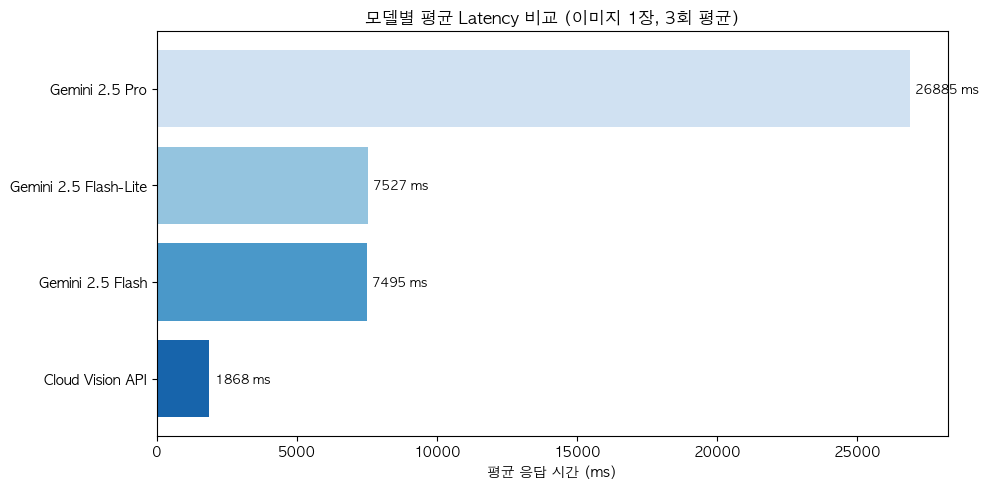

             model_id          display_name  avg_latency_ms
         cloud-vision      Cloud Vision API     1867.933333
     gemini-2.5-flash      Gemini 2.5 Flash     7495.200000
gemini-2.5-flash-lite Gemini 2.5 Flash-Lite     7527.033333
       gemini-2.5-pro        Gemini 2.5 Pro    26885.266667


In [29]:
latency_summary = (
    df.groupby(["model_id", "display_name"])["latency_ms"]
    .mean().reset_index()
    .rename(columns={"latency_ms": "avg_latency_ms"})
    .sort_values("avg_latency_ms")
)

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("Blues_r", len(latency_summary))
bars = ax.barh(latency_summary["display_name"], latency_summary["avg_latency_ms"],
               color=palette)
ax.bar_label(bars, fmt="%.0f ms", padding=4, fontsize=9)
ax.set_xlabel("평균 응답 시간 (ms)")
ax.set_title(f"모델별 평균 Latency 비교 (이미지 1장, {N_REPEAT}회 평균)")
plt.tight_layout(); plt.show()

print(latency_summary.to_string(index=False))


---
## 9. 비용 계산 및 시뮬레이션 <a id="9"></a>

In [30]:
def calc_cost(model_id: str, input_tok: int, output_tok: int) -> float | None:
    p = PRICING.get(model_id, {})
    if "input" in p and p["input"] is not None:
        return round((input_tok * p["input"] + output_tok * p["output"]) / 1_000_000, 6)
    elif "per_unit" in p:
        return round(p["per_unit"], 6)
    elif "per_page" in p:
        return round(p["per_page"], 6)
    return None

token_avg  = df.groupby("model_id")[["input_tokens", "output_tokens"]].mean()
cost_rows  = []
for model_id, row in token_avg.iterrows():
    cost = calc_cost(model_id, row["input_tokens"], row["output_tokens"])
    cost_rows.append({
        "model_id":           model_id,
        "avg_input_tokens":   round(row["input_tokens"]),
        "avg_output_tokens":  round(row["output_tokens"]),
        "cost_per_image_usd": cost,
        "cost_10k_usd":       round(cost * 10_000,    2) if cost else None,
        "cost_100k_usd":      round(cost * 100_000,   2) if cost else None,
        "cost_1m_usd":        round(cost * 1_000_000, 2) if cost else None,
    })

cost_df = pd.DataFrame(cost_rows)
print("\n💰 비용 시뮬레이션 (USD)")
print(cost_df[["model_id","cost_per_image_usd","cost_10k_usd","cost_100k_usd","cost_1m_usd"]].to_string(index=False))


💰 비용 시뮬레이션 (USD)
             model_id  cost_per_image_usd  cost_10k_usd  cost_100k_usd  cost_1m_usd
         cloud-vision            0.001500         15.00          150.0       1500.0
     gemini-2.5-flash            0.001870         18.70          187.0       1870.0
gemini-2.5-flash-lite            0.000447          4.47           44.7        447.0
       gemini-2.5-pro            0.008290         82.90          829.0       8290.0


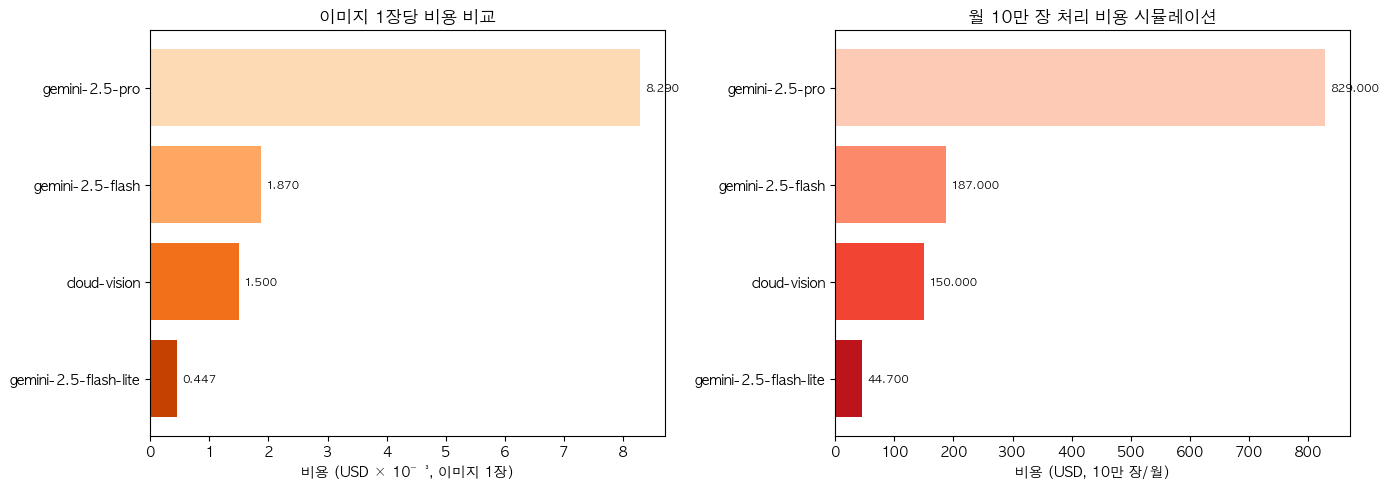

In [31]:
# ── 시각화 ───────────────────────────────────────────────────
valid = cost_df.dropna(subset=["cost_per_image_usd"]).sort_values("cost_per_image_usd")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(valid["model_id"], valid["cost_per_image_usd"] * 1000,
             color=sns.color_palette("Oranges_r", len(valid)))
axes[0].set_xlabel("비용 (USD × 10⁻³, 이미지 1장)")
axes[0].set_title("이미지 1장당 비용 비교")

axes[1].barh(valid["model_id"], valid["cost_100k_usd"],
             color=sns.color_palette("Reds_r", len(valid)))
axes[1].set_xlabel("비용 (USD, 10만 장/월)")
axes[1].set_title("월 10만 장 처리 비용 시뮬레이션")

for ax in axes:
    for bar in ax.patches:
        ax.text(bar.get_width() + ax.get_xlim()[1]*0.01,
                bar.get_y() + bar.get_height()/2,
                f"{bar.get_width():.3f}", va="center", fontsize=8)

plt.tight_layout(); plt.show()


---
## 10. 종합 비교 시각화 <a id="10"></a>

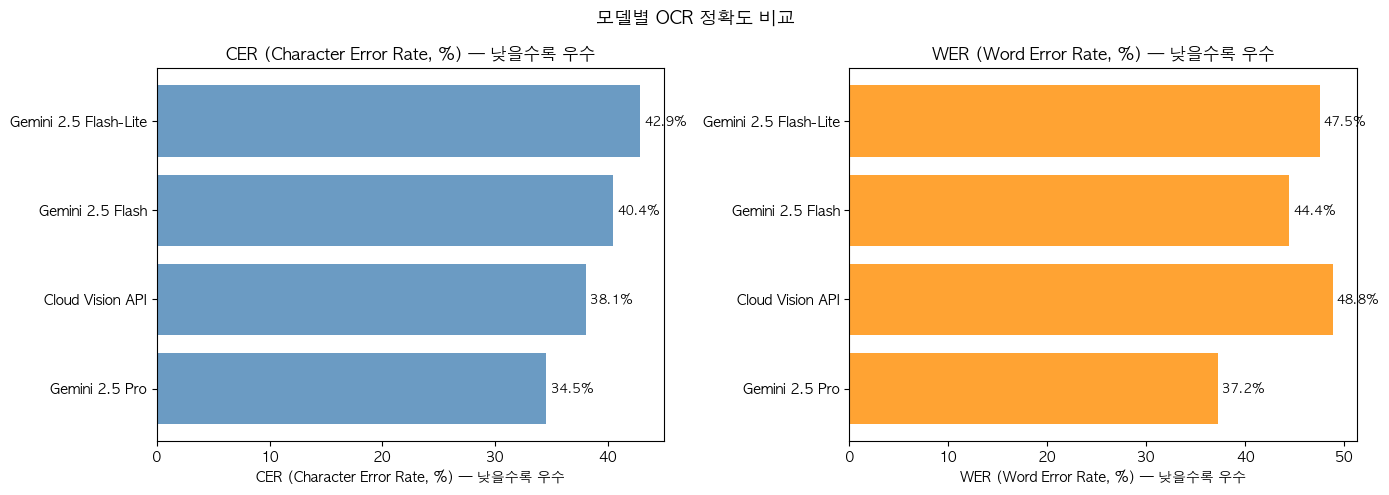

In [32]:
# ── CER / WER 모델별 평균 ──────────────────────────────────────
acc_summary = (
    df.groupby(["model_id", "display_name"])[["cer", "wer"]]
    .mean().reset_index().sort_values("cer")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric, title, color in zip(
    axes,
    ["cer", "wer"],
    ["CER (Character Error Rate, %) — 낮을수록 우수",
     "WER (Word Error Rate, %) — 낮을수록 우수"],
    ["steelblue", "darkorange"],
):
    valid = acc_summary.dropna(subset=[metric])
    bars = ax.barh(valid["display_name"], valid[metric], color=color, alpha=0.8)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
    ax.set_xlabel(title)
    ax.set_title(title)

plt.suptitle("모델별 OCR 정확도 비교", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


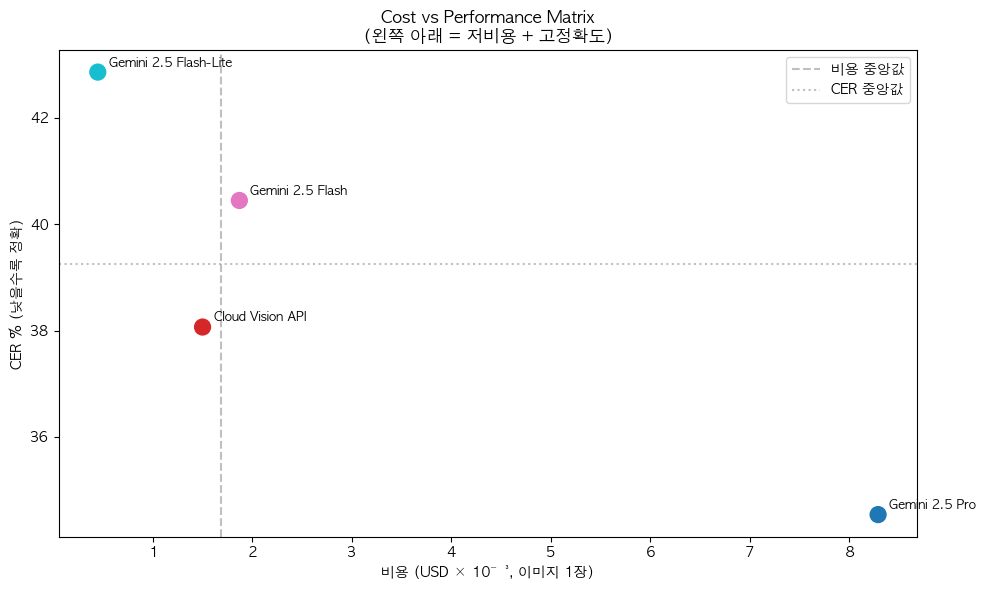

In [33]:
# ── Cost-Performance Scatter ─────────────────────────────────
merged = acc_summary.merge(
    cost_df[["model_id", "cost_per_image_usd"]], on="model_id", how="left"
).dropna(subset=["cer", "cost_per_image_usd"])

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(merged["cost_per_image_usd"] * 1000, merged["cer"],
           s=130, c=range(len(merged)), cmap="tab10", zorder=5)
for _, row in merged.iterrows():
    ax.annotate(row["display_name"],
                (row["cost_per_image_usd"] * 1000, row["cer"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)

ax.axvline(merged["cost_per_image_usd"].median() * 1000,
           color="gray", ls="--", alpha=0.5, label="비용 중앙값")
ax.axhline(merged["cer"].median(), color="gray", ls=":", alpha=0.5, label="CER 중앙값")
ax.set_xlabel("비용 (USD × 10⁻³, 이미지 1장)")
ax.set_ylabel("CER % (낮을수록 정확)")
ax.set_title("Cost vs Performance Matrix\n(왼쪽 아래 = 저비용 + 고정확도)")
ax.legend()
plt.tight_layout()
plt.show()

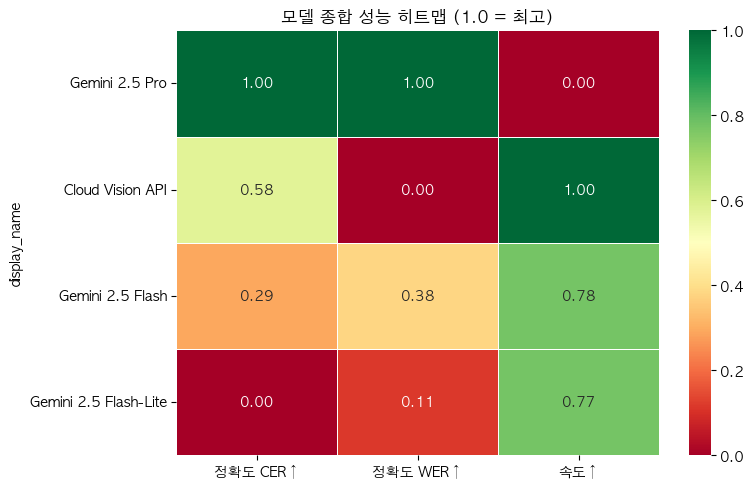

In [34]:
# ── 종합 히트맵 ──────────────────────────────────────────────
summary_tbl = acc_summary.set_index("display_name")[["cer", "wer"]].copy()
summary_tbl = summary_tbl.merge(
    latency_summary.set_index("display_name")[["avg_latency_ms"]],
    left_index=True, right_index=True, how="left"
)
norm_df = pd.DataFrame(index=summary_tbl.index)
for col, label in [("cer","정확도 CER↑"),("wer","정확도 WER↑"),("avg_latency_ms","속도↑")]:
    mn, mx = summary_tbl[col].min(), summary_tbl[col].max()
    norm_df[label] = 1 - (summary_tbl[col] - mn) / (mx - mn + 1e-9)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(norm_df, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title("모델 종합 성능 히트맵 (1.0 = 최고)")
plt.tight_layout(); plt.show()


In [35]:
# ── 이미지별 추출 텍스트 상세 비교 ───────────────────────────
for img_key, meta in TEST_IMAGES.items():
    print(f"\n{'='*70}")
    print(f"📄 {meta['desc']}")
    print(f"{'='*70}")
    subset = df[df["image"] == img_key]
    for _, row in subset.iterrows():
        print(f"\n  ┌─ [{row['display_name']}] CER={row['cer']}%  WER={row['wer']}%  latency={row['latency_ms']}ms")
        lines = (row["extracted_text"] or "").split("\n")[:10]
        for line in lines:
            print(f"  │  {line}")
        if len((row["extracted_text"] or "").split("\n")) > 10:
            print("  │  ...(이하 생략)")
        print("  └─")


📄 햇반 현미귀리곤약밥 상세 (제품 소개)

  ┌─ [Gemini 2.5 Flash-Lite] CER=68.35%  WER=73.49%  latency=13636.2ms
  │  햇반
  │  건강한 습관, 라이스플랜
  │  현미귀리곤약밥
  │  연출이미지
  │  *1등 햇반이 완성한 밥 소믈리에의 황금배합!
  │  *2001-2024, 즉석밥 부문 판매실적 1위 기업, 닐슨 조사결과
  │  고식이섬유
  │  한공기
  │  8.7g 165 Kcal
  │  대한민국
  │  ...(이하 생략)
  └─

  ┌─ [Gemini 2.5 Flash] CER=64.36%  WER=70.32%  latency=10993.3ms
  │  햇반
  │  건강한 습관, 라이스플랜
  │  현미귀리곤약밥
  │  연출이미지
  │  *1등 햇반이 완성한 밥 소믈리에의 황금배합!
  │  *2001-2024, 즉석밥 부문 판매실적 1위 기업, 닐슨 조사결과
  │  고식이섬유
  │  8.7g
  │  한공기
  │  165Kcal
  │  ...(이하 생략)
  └─

  ┌─ [Gemini 2.5 Pro] CER=48.83%  WER=52.45%  latency=24850.7ms
  │  햇반®
  │  건강한 습관, 라이스플랜
  │  현미귀리곤약밥
  │  
  │  연출이미지
  │  
  │  *1등 햇반이 완성한 밥 소믈리에의 황금배합!
  │  *2001-2024, 즉석밥 부문 판매실적 1위 기업, 닐슨 조사결과
  │  
  │  고식이섬유
  │  ...(이하 생략)
  └─

  ┌─ [Cloud Vision API] CER=60.89%  WER=73.49%  latency=4293.8ms
  │  햇반
  │  건강한 습관, 라이스플랜
  │  현미귀리곤약밥
  │  연출이미지
  │  "1등 햇반이 완성한 밥 소믈리에의 황금배합!
  │  *2001-2024, 즉석밥 부문 판매실적 1위 기업 닐슨 조사결과
  │  고식이섬유
  │  한

---
## 11. 결과 저장 <a id="11"></a>

In [36]:
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "ocr_results_detail.csv",  index=False, encoding="utf-8-sig")
cost_df.to_csv(OUTPUT_DIR / "cost_simulation.csv",  index=False, encoding="utf-8-sig")
acc_summary.to_csv(OUTPUT_DIR / "accuracy_summary.csv", index=False, encoding="utf-8-sig")

text_dump = {img_key: {} for img_key in TEST_IMAGES}
for _, row in df.iterrows():
    text_dump[row["image"]][row["model_id"]] = row["extracted_text"]
with open(OUTPUT_DIR / "extracted_texts.json", "w", encoding="utf-8") as f:
    json.dump(text_dump, f, ensure_ascii=False, indent=2)

print("✅ 결과 저장 완료")
print(f"   📁 {OUTPUT_DIR}/")
print("      ├─ ocr_results_detail.csv")
print("      ├─ accuracy_summary.csv")
print("      ├─ cost_simulation.csv")
print("      └─ extracted_texts.json")


✅ 결과 저장 완료
   📁 results/
      ├─ ocr_results_detail.csv
      ├─ accuracy_summary.csv
      ├─ cost_simulation.csv
      └─ extracted_texts.json


---
## ✅ 실험 체크리스트

| 단계 | 항목 | 완료 |
|------|------|:----:|
| 환경 |  설정 | ☐ |
| 환경 | GCP 서비스 계정 JSON 경로 설정 | ☐ |
| 환경 | ,  설정 | ☐ |
| 이미지 |  폴더에 3장 저장 | ☐ |
| Document AI |  /  입력 | ☐ |
| GT |  딕셔너리 텍스트 검토·수정 | ☐ |
| 실행 | Kernel Restart → 전체 셀 Run All | ☐ |
| 보고서 |  데이터로 보고서 5장 업데이트 | ☐ |

> **Gemini 3.0 Preview 모델 ID**: 정식 출시 전이라 실제 API 호출 가능 여부 확인 후  
>  딕셔너리의 모델 ID를 수정하세요.
